## 1D

In [1]:
#test 1

from ectuner.libs.config import Config
from ectuner.libs.logger import setup_logger
from ectuner.ectuner import run_1d_tuning
import os

logger = setup_logger(level='INFO')

# config
config_path = '/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/ectuner/myconfigs/myconfig_415_LR.yaml'
out_dir = '/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/1d/notebook/'
os.makedirs(out_dir, exist_ok=True)

cfg = Config(config_path, exp = 'phis', year1= 2000, year2 = 2017, out_dir = out_dir)

res = run_1d_tuning(cfg, logger)

2026-07-19 09:15:09 | ectuner |     INFO -> ==== Starting ECtuner 1D Workflow ====
2026-07-19 09:15:11 | ectuner |     INFO -> 
---------------- PHYSICS-BASED REFERENCE ADJUSTMENTS (Target Shifts) ----------------
2026-07-19 09:15:11 | ectuner |     INFO -> net_toa      | Global |     1.0160 |     1.0160 |      +0.0000 W/m2
2026-07-19 09:15:11 | ectuner |     INFO -> rsnt         | Global |   241.5560 |   241.5560 |      +0.0000 W/m2
2026-07-19 09:15:11 | ectuner |     INFO -> rlnt         | Global |  -240.5400 |  -240.5400 |      +0.0000 W/m2
2026-07-19 09:15:11 | ectuner |     INFO -> -------------------------------------------------------------------------------------

2026-07-19 09:15:11 | ectuner |     INFO -> Starting Optimization (dual_annealing)...
2026-07-19 09:15:16 | ectuner |     INFO -> Optimization finished. Final Global Score: 0.2412


In [2]:
from ectuner.libs.exporter import print_summary, save_diagnostics_yaml

print_summary(res, logger)

diag_yaml_path = os.path.join(out_dir, 'diagnostics_phis_1D.yaml')
save_diagnostics_yaml(res, diag_yaml_path)

2026-07-19 09:15:29 | ectuner |     INFO -> 
Parameters Optimization Result:
2026-07-19 09:15:29 | ectuner |     INFO -> --------------------------------------------------------------------------------
2026-07-19 09:15:29 | ectuner |     INFO -> |     Parameter     |   New value |   Old value |      Change |   Rel. change |   Min change |   Max change |   Dist. from ref. |
2026-07-19 09:15:29 | ectuner |     INFO -> |-------------------+-------------+-------------+-------------+---------------+--------------+--------------+-------------------|
2026-07-19 09:15:29 | ectuner |     INFO -> |      RPRCON       |  1.1202e-03 |  1.4000e-03 | -2.7979e-04 |   -1.9985e-01 |  -2.8000e-04 |   2.8000e-04 |       -1.9985e-01 |
2026-07-19 09:15:29 | ectuner |     INFO -> |      ENTRORG      |  2.0992e-03 |  1.7500e-03 |  3.4915e-04 |    1.9952e-01 |  -3.5000e-04 |   3.5000e-04 |        1.9952e-01 |
2026-07-19 09:15:29 | ectuner |     INFO -> |      DETRPEN      |  8.9878e-05 |  7.5000e-05 |  1.4878e

Diagnostic YAML written to: /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/1d/notebook/diagnostics_phis_1D.yaml


In [3]:

# es
print("\n--- Exploration ---")
print(f"Initial score: {res.metrics['score_init']:.4f}")
print(f"Final score: {res.metrics['total_global_cost']:.4f}")
print(f"New RMINICE value: {res.get_new_parameters()['RMINICE']}")


--- Exploration ---
Initial score: 32.0379
Final score: 0.2417
New RMINICE value: 71.99982432816103


In [4]:
import pandas as pd
df = pd.DataFrame(res.bias_evaluation['targets'])

In [5]:
print(df[['variable', 'model_init', 'model_final', 'ref_val']])

  variable  model_init  model_final  ref_val
0  net_toa    6.676206     1.504928    1.016


In [6]:
res.optimal_changes

{'RPRCON': np.float64(-0.0002798086345392808),
 'ENTRORG': np.float64(0.00034980238841418143),
 'DETRPEN': np.float64(1.4992994386025082e-05),
 'ENTRDD': np.float64(-5.9671462736958904e-05),
 'RMFDEPS': np.float64(0.059905858075283785),
 'RVICE': np.float64(0.025948980775619898),
 'RLCRITSNOW': np.float64(-3.99837496315177e-06),
 'RSNOWLIN2': np.float64(-0.005994311769645468),
 'RCLDIFF': np.float64(-1.1964972174203662e-06),
 'RCLDIFF_CONVI': np.float64(-1.9993735892660682),
 'RDEPLIQREFRATE': np.float64(-0.09961746392918275),
 'RDEPLIQREFDEPTH': np.float64(-99.98361733344166),
 'RCL_OVERLAPLIQICE': np.float64(-0.12980401546909337),
 'RCL_INHOMOGAUT': np.float64(-0.29999335957973106),
 'RCL_INHOMOGACC': np.float64(-0.599758337536789),
 'RMINICE': np.float64(11.995991027073515)}

/etc/ecmwf/nfs/dh2_2_perm_b/ecme3038/envs/ectuner/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Loaded 1 diagnostic files from /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/1d/notebook/


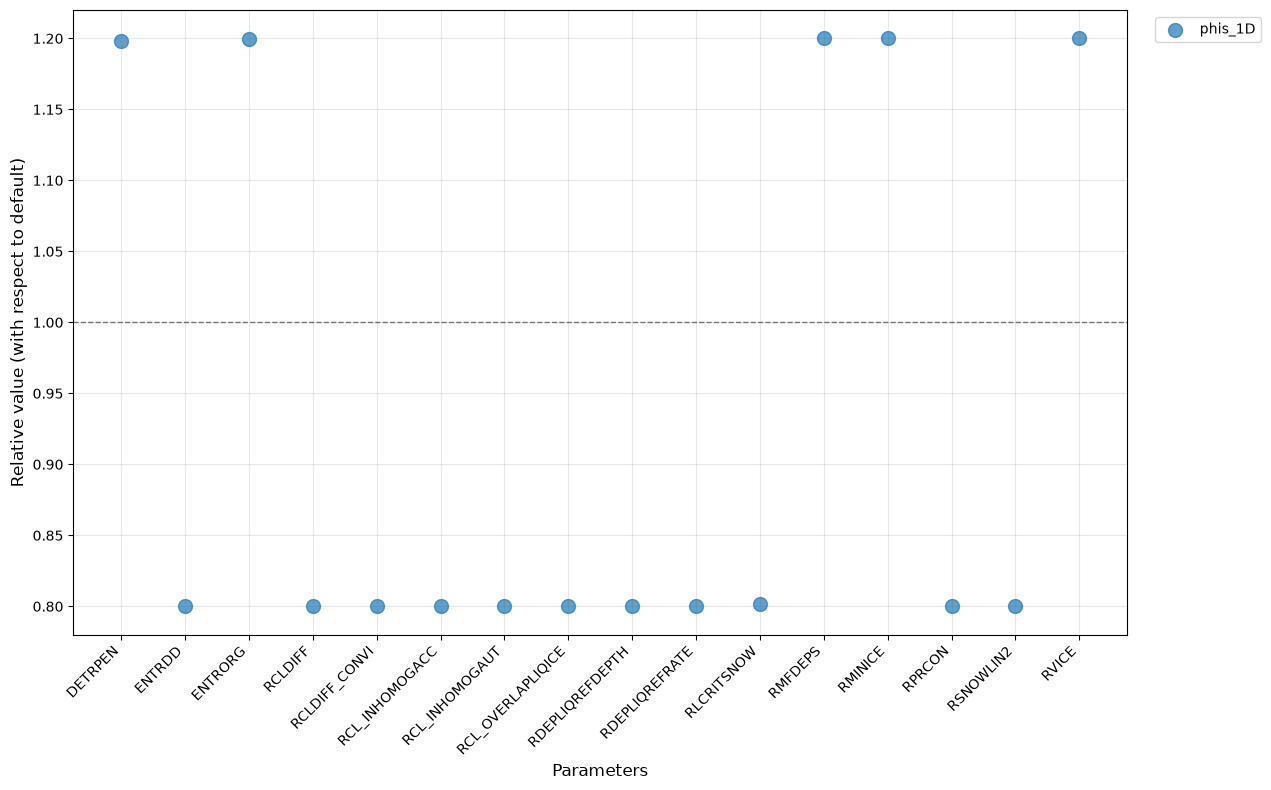

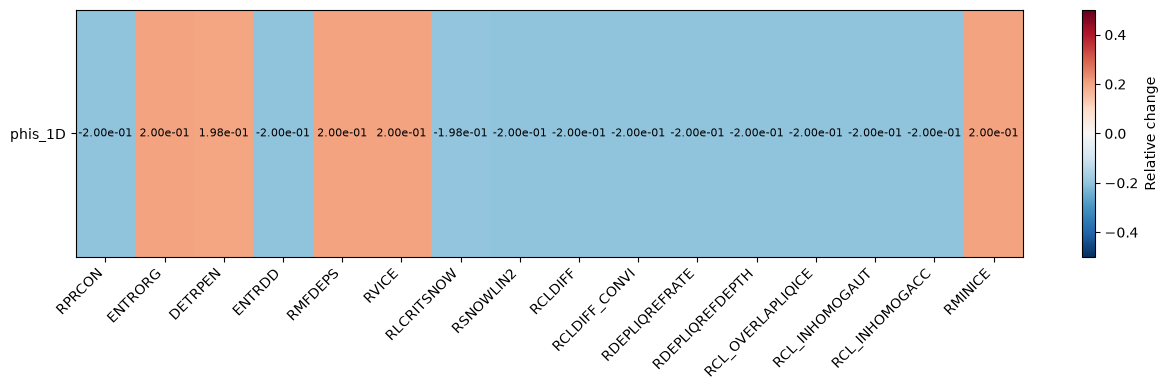

In [3]:
from ectuner.libs.diagnostics import load_diagnostic_yamls, plot_parameter_scatter, plot_parameter_heatmap

# Carica tutti i file diagnostics_*.yaml che hai appena generato
out_dir = '/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/1d/notebook/'
data = load_diagnostic_yamls(out_dir)

plot_parameter_scatter(data)
plot_parameter_heatmap(data)

### Test cycle for

In [1]:
from ectuner.libs.config import Config
from ectuner.libs.logger import setup_logger
from ectuner.ectuner import run_1d_tuning
from ectuner.libs.exporter import save_diagnostics_yaml
import os

In [2]:
# 1. Carica la configurazione base una volta sola
logger = setup_logger(level='INFO')
base_config_path = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/ectuner/myconfigs/myconfig_415_LR.yaml"
out_dir = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/1d/sweep/"
os.makedirs(out_dir, exist_ok=True)

In [3]:
test_cases = [
    {'tag': 'inc_0.4', 'inc': 0.4, 'frozen': {}},
    {'tag': 'inc_0.6', 'inc': 0.6, 'frozen': {}},
    {'tag': 'frozen_entrorg', 'inc': 0.2, 'frozen': {'ENTRORG': 0.005}} # Forza un valore!
]

for test in test_cases:
    print(f"\n--- Running Test: {test['tag']} ---")
    
    # Inizializza un config fresco per ogni run
    cfg = Config(base_config_path, exp="phis", year1=2000, year2=2017)
    
    # Inietta le modifiche
    cfg.set('args.inc', test['inc'])
    cfg.set('frozen_parameters', test['frozen'])
    
    # Lancia l'ottimizzatore
    result = run_1d_tuning(cfg, logger)
    
    # Salva la diagnostica per i plot successivi
    diag_path = os.path.join(out_dir, f"diagnostics_{test['tag']}.yaml")
    save_diagnostics_yaml(result, diag_path)

2026-07-19 10:31:16 | ectuner |     INFO -> ==== Starting ECtuner 1D Workflow ====



--- Running Test: inc_0.4 ---


2026-07-19 10:31:18 | ectuner |     INFO -> 
---------------- PHYSICS-BASED REFERENCE ADJUSTMENTS (Target Shifts) ----------------
2026-07-19 10:31:18 | ectuner |     INFO -> net_toa      | Global |     1.0160 |     1.0160 |      +0.0000 W/m2
2026-07-19 10:31:18 | ectuner |     INFO -> rsnt         | Global |   241.5560 |   241.5560 |      +0.0000 W/m2
2026-07-19 10:31:18 | ectuner |     INFO -> rlnt         | Global |  -240.5400 |  -240.5400 |      +0.0000 W/m2
2026-07-19 10:31:18 | ectuner |     INFO -> -------------------------------------------------------------------------------------

2026-07-19 10:31:18 | ectuner |     INFO -> Starting Optimization (dual_annealing)...
2026-07-19 10:31:20 | ectuner |     INFO -> Optimization finished. Final Global Score: 0.0000
2026-07-19 10:31:20 | ectuner |     INFO -> ==== Starting ECtuner 1D Workflow ====


Diagnostic YAML written to: /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/1d/sweep/diagnostics_inc_0.4.yaml

--- Running Test: inc_0.6 ---


2026-07-19 10:31:22 | ectuner |     INFO -> 
---------------- PHYSICS-BASED REFERENCE ADJUSTMENTS (Target Shifts) ----------------
2026-07-19 10:31:22 | ectuner |     INFO -> net_toa      | Global |     1.0160 |     1.0160 |      +0.0000 W/m2
2026-07-19 10:31:22 | ectuner |     INFO -> rsnt         | Global |   241.5560 |   241.5560 |      +0.0000 W/m2
2026-07-19 10:31:22 | ectuner |     INFO -> rlnt         | Global |  -240.5400 |  -240.5400 |      +0.0000 W/m2
2026-07-19 10:31:22 | ectuner |     INFO -> -------------------------------------------------------------------------------------

2026-07-19 10:31:22 | ectuner |     INFO -> Starting Optimization (dual_annealing)...
2026-07-19 10:31:24 | ectuner |     INFO -> Optimization finished. Final Global Score: 0.0000
2026-07-19 10:31:24 | ectuner |     INFO -> ==== Starting ECtuner 1D Workflow ====


Diagnostic YAML written to: /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/1d/sweep/diagnostics_inc_0.6.yaml

--- Running Test: frozen_entrorg ---


2026-07-19 10:31:26 | ectuner |     INFO -> 
---------------- PHYSICS-BASED REFERENCE ADJUSTMENTS (Target Shifts) ----------------
2026-07-19 10:31:26 | ectuner |     INFO -> net_toa      | Global |     1.0160 |     1.0160 |      +0.0000 W/m2
2026-07-19 10:31:26 | ectuner |     INFO -> rsnt         | Global |   241.5560 |   241.5560 |      +0.0000 W/m2
2026-07-19 10:31:26 | ectuner |     INFO -> rlnt         | Global |  -240.5400 |  -240.5400 |      +0.0000 W/m2
2026-07-19 10:31:26 | ectuner |     INFO -> -------------------------------------------------------------------------------------

2026-07-19 10:31:27 | ectuner |     INFO -> Frozen parameters (keeping manual tuning): ENTRORG
2026-07-19 10:31:27 | ectuner |     INFO -> [Pre-Shift 1D] Absorbing frozen parameter 'ENTRORG' (delta_p: 3.250000e-03)
2026-07-19 10:31:27 | ectuner |     INFO -> Starting Optimization (dual_annealing)...
2026-07-19 10:31:31 | ectuner |     INFO -> Optimization finished. Final Global Score: 34.5502


Diagnostic YAML written to: /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/1d/sweep/diagnostics_frozen_entrorg.yaml


/etc/ecmwf/nfs/dh2_2_perm_b/ecme3038/envs/ectuner/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Loaded 3 diagnostic files from /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/1d/sweep/


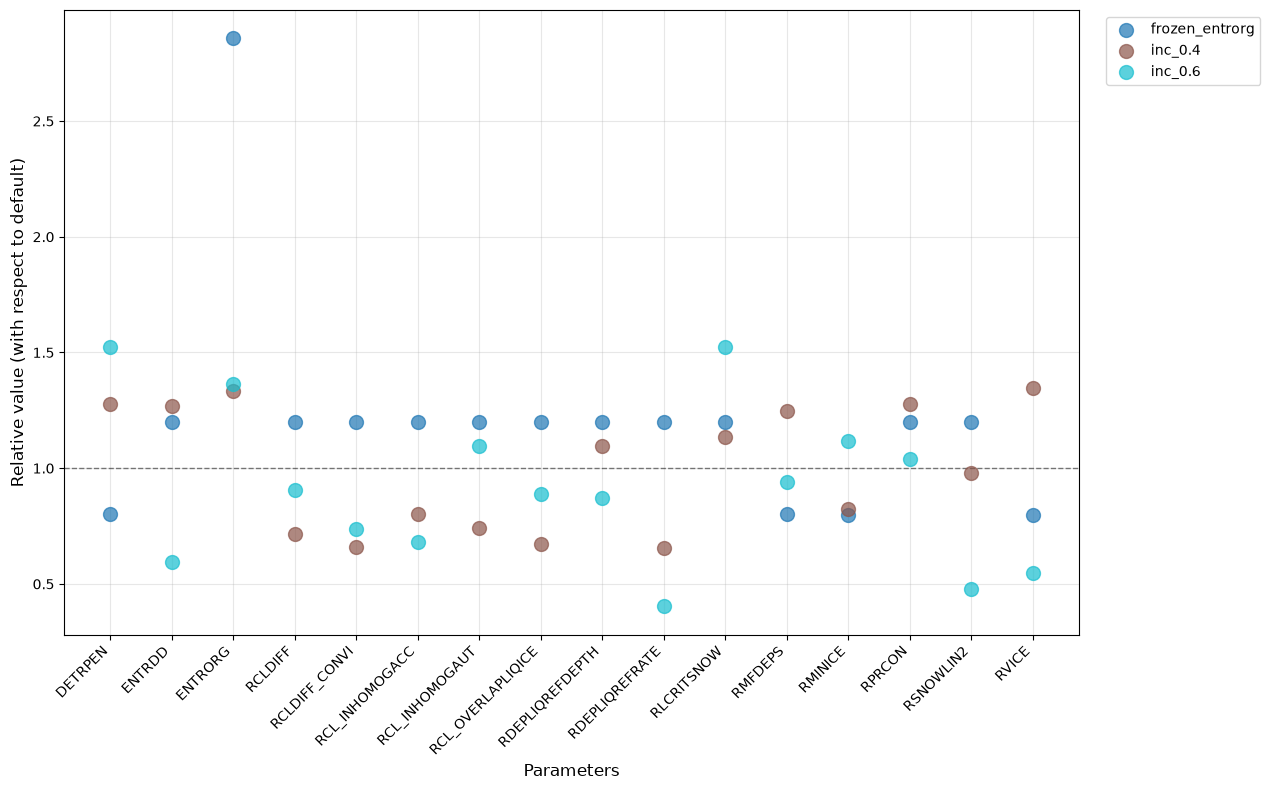

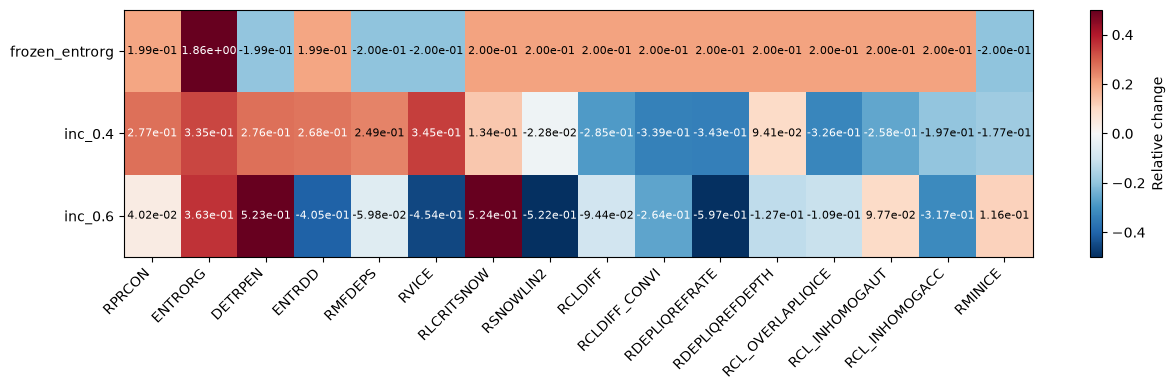

In [4]:
from ectuner.libs.diagnostics import (
    load_diagnostic_yamls, 
    plot_parameter_scatter,
    plot_parameter_heatmap
)

# 1. Carica tutti i file YAML che hai appena generato
diag_data = load_diagnostic_yamls(out_dir)

# 2. Plot dello scatter dei parametri (vedrai come cambia ENTRORG nel caso frozen!)
plot_parameter_scatter(diag_data)
plot_parameter_heatmap(diag_data)

## 2D

### Test Tuner2D

In [ ]:
#test 1

from ectuner.libs.config import Config
from ectuner.libs.logger import setup_logger
from ectuner.ectuner import run_2d_tuning
import os

logger = setup_logger(level='INFO')

# config
config_path = '/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/ectuner/myconfigs/myconfig_415_LR.yaml'
out_dir = '/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/notebook/'
os.makedirs(out_dir, exist_ok=True)

cfg = Config(config_path, exp = 'phis', year1= 2000, year2 = 2017)

cfg.set('files.output_dir', out_dir)

res_2d = run_2d_tuning(cfg, logger)

2026-07-19 14:07:10 | ectuner |     INFO -> ==== Starting ECtuner 2D Spatial Workflow ====
2026-07-19 14:07:10 | ectuner |     INFO -> Loading 2D Data (Sensitivity, Reference, Base)...
2026-07-19 14:07:10 | ectuner |     INFO -> Loading 2D sensitivity from: /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/data/sensitivities/2D/sensitivity_TL63_415_1991-2000_2D.nc
/etc/ecmwf/nfs/dh2_2_perm_b/ecme3038/envs/ectuner/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
2026-07-19 14:07:18 | ectuner |     INFO -> Loading reference for net_toa from: climate_average_net_toa_CERES EBAF_r180x90_2000-2024.nc
2026-07-19 14:07:18 | ectuner |     INFO -> Loading reference for rsnt from: climate_average_rsnt_CERES EBAF_r180x90_2000-2024.nc
2026-07-19 14:07:18 | ectuner |     INFO -> Loading reference for rlnt from: climate_average_rlnt_CERES EBAF_r180x90_2000-2024.nc
2026-07-19 14:07:18 | ectuner |    

In [ ]:
from ectuner.libs.exporter import print_summary, save_diagnostics_yaml

print_summary(res_2d, logger)

diag_yaml_path_2d = os.path.join(out_dir, 'diagnostics_phis_2D.yaml')
save_diagnostics_yaml(res_2d, diag_yaml_path_2d)

2026-07-19 14:11:41 | ectuner |     INFO -> 
Parameters Optimization Result:
2026-07-19 14:11:41 | ectuner |     INFO -> --------------------------------------------------------------------------------
2026-07-19 14:11:41 | ectuner |     INFO -> |     Parameter     |   New value |   Old value |      Change |   Rel. change |   Min change |   Max change |   Dist. from ref. |
2026-07-19 14:11:41 | ectuner |     INFO -> |-------------------+-------------+-------------+-------------+---------------+--------------+--------------+-------------------|
2026-07-19 14:11:41 | ectuner |     INFO -> |      RPRCON       |  1.1202e-03 |  1.4000e-03 | -2.7976e-04 |   -1.9983e-01 |  -2.8000e-04 |   2.8000e-04 |       -1.9983e-01 |
2026-07-19 14:11:41 | ectuner |     INFO -> |      ENTRORG      |  1.6017e-03 |  1.7500e-03 | -1.4828e-04 |   -8.4729e-02 |  -3.5000e-04 |   3.5000e-04 |       -8.4729e-02 |
2026-07-19 14:11:41 | ectuner |     INFO -> |      DETRPEN      |  8.9989e-05 |  7.5000e-05 |  1.4989e

Diagnostic YAML written to: /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/notebook/diagnostics_phis_2D.yaml


Loaded 1 diagnostic files from /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/notebook/


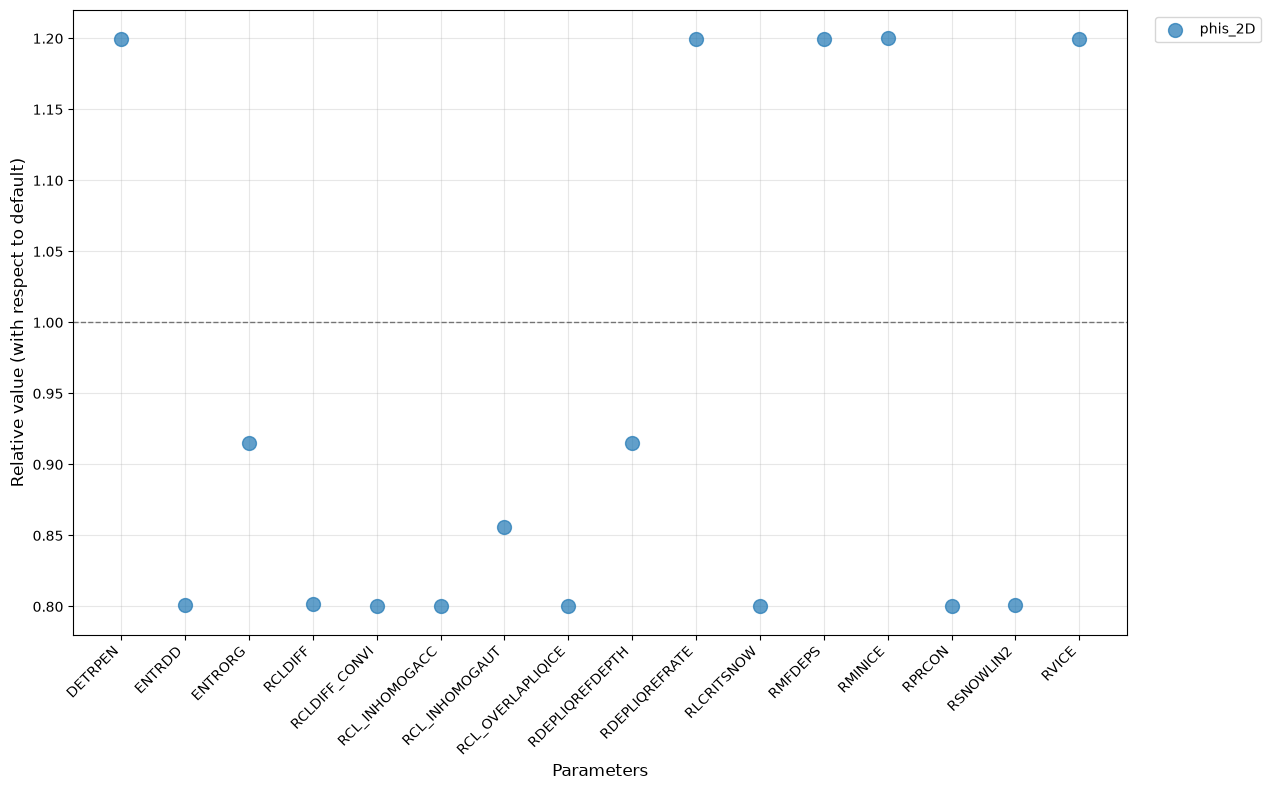

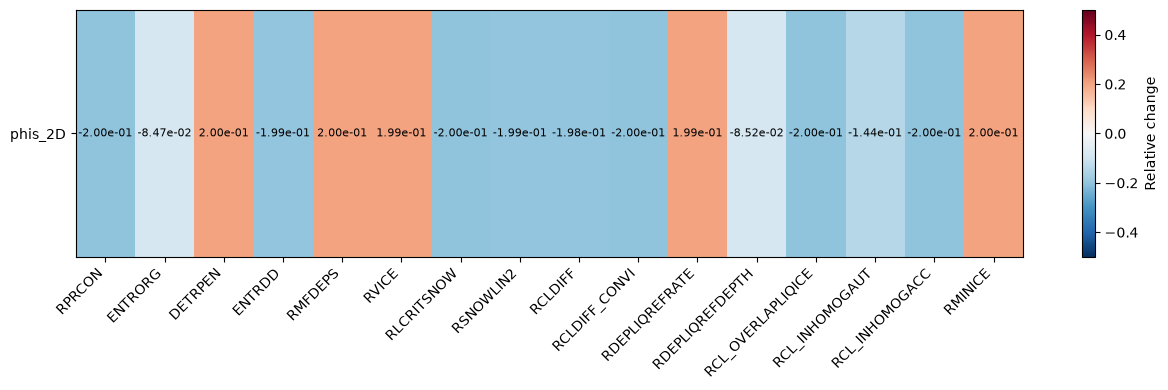

In [3]:
from ectuner.libs.diagnostics import load_diagnostic_yamls, plot_parameter_scatter, plot_parameter_heatmap

# Carica tutti i file diagnostics_*.yaml che hai appena generato
out_dir_2d = '/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/notebook/'
data_2d = load_diagnostic_yamls(out_dir_2d)

plot_parameter_scatter(data_2d)
plot_parameter_heatmap(data_2d)

### Test SLURM

In [1]:
import os
from ectuner.libs.config import Config
from ectuner.libs.automation import ExperimentSLURM

base_config_path = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/ectuner/myconfigs/myconfig_415_LR.yaml"
job_template_path = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/jobs/run_tuner_sweep.sh"  
output_directory = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/sweep/"

os.makedirs(output_directory, exist_ok=True)

base_config = Config(base_config_path, exp="phis", year1=2000, year2=2017)
base_config.set('files.output_dir', output_directory)

test_cases = [
    {'tag': 'a00_spatial', 'alpha': 0.0, 'frozen': {}},       # spatial
    {'tag': 'a05_hybrid',  'alpha': 0.5, 'frozen': {}},       # 50/50
    {'tag': 'a10_global',  'alpha': 1.0, 'frozen': {}},       # global
    {'tag': 'a05_frozen',  'alpha': 0.5, 'frozen': {'ENTRORG': 0.005}} # Test Pre-Shift 2D
]

print("Start SLURM job submission...")
for test in test_cases:
    exp = ExperimentSLURM(base_config, exp_name="phis")
    
    exp.set('spatial_tuning.alpha', test['alpha'])
    exp.set('frozen_parameters', test['frozen'])
  
    try:
        exp.submit(job_template_path, run_tag=test['tag'])
    except Exception as e:
        print(f"Error submitting job {test['tag']}: {e}")

print("All jobs have been submitted. Use 'squeue -u $USER' in the terminal to monitor them.")

Start SLURM job submission...
Submitted batch job 30778689
>>> Job a00_spatial sent.
Submitted batch job 30778690
>>> Job a05_hybrid sent.
Submitted batch job 30778693
>>> Job a10_global sent.
Submitted batch job 30778696
>>> Job a05_frozen sent.
All jobs have been submitted. Use 'squeue -u $USER' in the terminal to monitor them.


Yaml upload...
Loaded 4 diagnostic files from /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/2d/sweep/


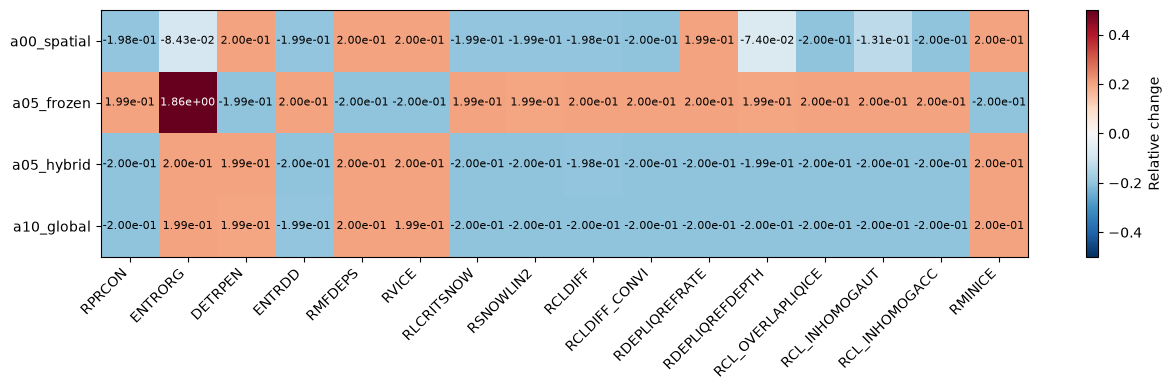

,Alpha,Metric,Raw_Spatial_Cost,Raw_Global_Cost,Metric_Type,Phys_Spatial_Total,Phys_Global_Total,net_toa_AbsBias
Experiment,,,,,,,,
a00_spatial,0.0,l1,7.395561,2.948694,L1 (Linear),7.395561,2.948694,2.948694
a05_frozen,0.5,l1,15.263820,5.910434,L1 (Linear),15.263820,5.910434,5.910434
a05_hybrid,0.5,l1,7.902205,0.454873,L1 (Linear),7.902205,0.454873,0.454873
a10_global,1.0,l1,7.901190,0.460641,L1 (Linear),7.901190,0.460641,0.460641


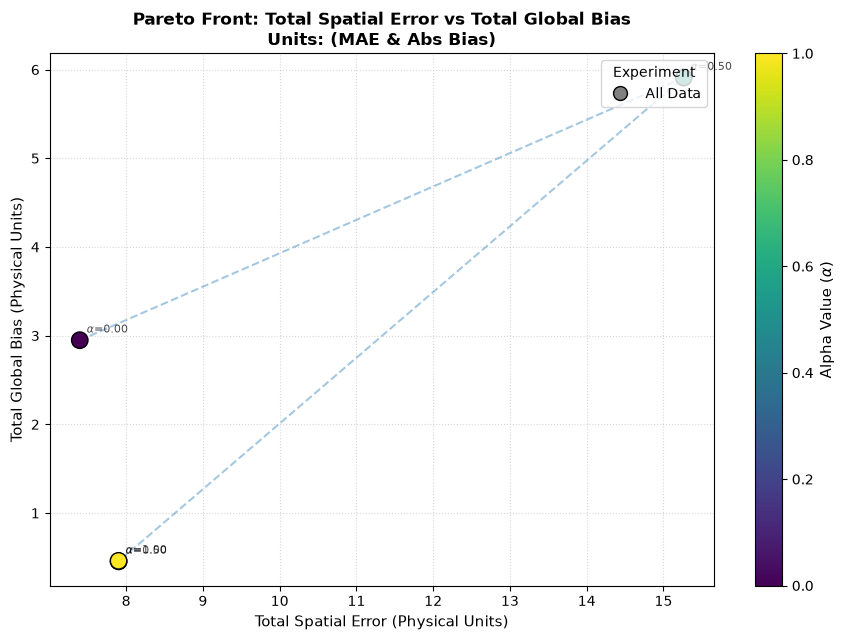


Generating 2D Maps...

Mappe per il run: a05_hybrid

Mappe per il run: a05_frozen

Mappe per il run: a10_global

Mappe per il run: a00_spatial


In [4]:
import os
import glob
from ectuner.libs.diagnostics import (
    load_diagnostic_yamls, 
    build_metrics_dataframe, 
    plot_tradeoff_comparison,
    plot_parameter_heatmap,
    plot_tuning_results_maps
)

out_dir = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/sweep/"

# ---------------------------------------------------------
# 1. Parameters and Trade-Off Analysis (based on YAML files)
# ---------------------------------------------------------
print("Yaml upload...")
diag_data = load_diagnostic_yamls("/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/2d/sweep/")

plot_parameter_heatmap(diag_data)

# pareto front (Spatial Error vs Global Bias)
df_metrics = build_metrics_dataframe(diag_data)
display(df_metrics) # Visualizza la tabella interattiva
plot_tradeoff_comparison(df_metrics, group_by='Experiment')

# ---------------------------------------------------------
# 2. Spatial Analysis (based on NetCDF files)
# ---------------------------------------------------------
print("\nGenerating 2D Maps...")
# Find all generated diagnostic NetCDF files
nc_files = glob.glob(os.path.join(out_dir, "diagnostics_2d_*.nc"))

# experiment maps
for nc_file in nc_files:
    run_tag = os.path.basename(nc_file).replace('.nc', '').replace('diagnostics_2d_phis_', '')
    print(f"\nMappe per il run: {run_tag}")
    
    plot_tuning_results_maps(
        diag_file=nc_file, 
        output_dir=os.path.join(out_dir, "plots"), 
        run_tag=run_tag
    )

### NET_TOA, inc=0.3

In [3]:
import os
from ectuner.libs.config import Config
from ectuner.libs.automation import ExperimentSLURM

base_config_path = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/ectuner/myconfigs/myconfig_415_LR.yaml"
job_template_path = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/jobs/run_tuner_sweep.sh"  
output_directory = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/net_toa/"

os.makedirs(output_directory, exist_ok=True)

base_config = Config(base_config_path, exp="phis", year1=2000, year2=2017)
base_config.set('files.output_dir', output_directory)

test_cases = [
    {'tag': 'a01_spatial', 'alpha': 0.1, 'frozen': {}},       # spatial
    {'tag': 'a02_spatial', 'alpha': 0.2, 'frozen': {}},       # 
    # {'tag': 'a05_hybrid',  'alpha': 0.5, 'frozen': {}},       # 50/50
    # {'tag': 'a07_spatial', 'alpha': 0.7, 'frozen': {}},       # 
    # {'tag': 'a10_global',  'alpha': 1.0, 'frozen': {}},       # global
]

print("Start SLURM job submission...")
for test in test_cases:
    exp = ExperimentSLURM(base_config, exp_name="phis")
    
    exp.set('spatial_tuning.alpha', test['alpha'])
    exp.set('frozen_parameters', test['frozen'])
  
    try:
        exp.submit(job_template_path, run_tag=test['tag'])
    except Exception as e:
        print(f"Error submitting job {test['tag']}: {e}")

print("All jobs have been submitted. Use 'squeue -u $USER' in the terminal to monitor them.")

Start SLURM job submission...
Submitted batch job 30805052
>>> Job a01_spatial sent.
Submitted batch job 30805054
>>> Job a02_spatial sent.
All jobs have been submitted. Use 'squeue -u $USER' in the terminal to monitor them.


Yaml upload...
Loaded 7 diagnostic files from /ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/2d/net_toa/


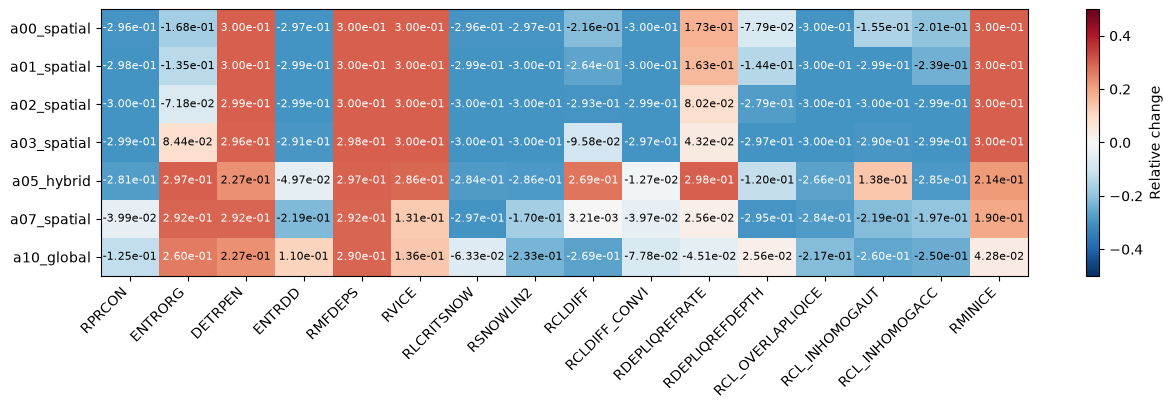

,Alpha,Metric,Raw_Spatial_Cost,Raw_Global_Cost,Metric_Type,Phys_Spatial_Total,Phys_Global_Total,net_toa_AbsBias
Experiment,,,,,,,,
a00_spatial,0.0,l1,7.055744,2.705418e+00,L1 (Linear),7.055744,2.705418e+00,2.705418e+00
a01_spatial,0.1,l1,7.096386,1.933063e+00,L1 (Linear),7.096386,1.933063e+00,1.933063e+00
a02_spatial,0.2,l1,7.268279,9.762096e-01,L1 (Linear),7.268279,9.762096e-01,9.762096e-01
a03_spatial,0.3,l1,7.611466,1.800874e-08,L1 (Linear),7.611466,1.800874e-08,1.800873e-08
a05_hybrid,0.5,l1,7.981211,1.400480e-11,L1 (Linear),7.981211,1.400480e-11,1.399136e-11
a07_spatial,0.7,l1,8.102885,2.104411e-04,L1 (Linear),8.102885,2.104411e-04,2.104411e-04
a10_global,1.0,l1,8.279330,1.783462e-12,L1 (Linear),8.279330,1.783462e-12,1.765080e-12


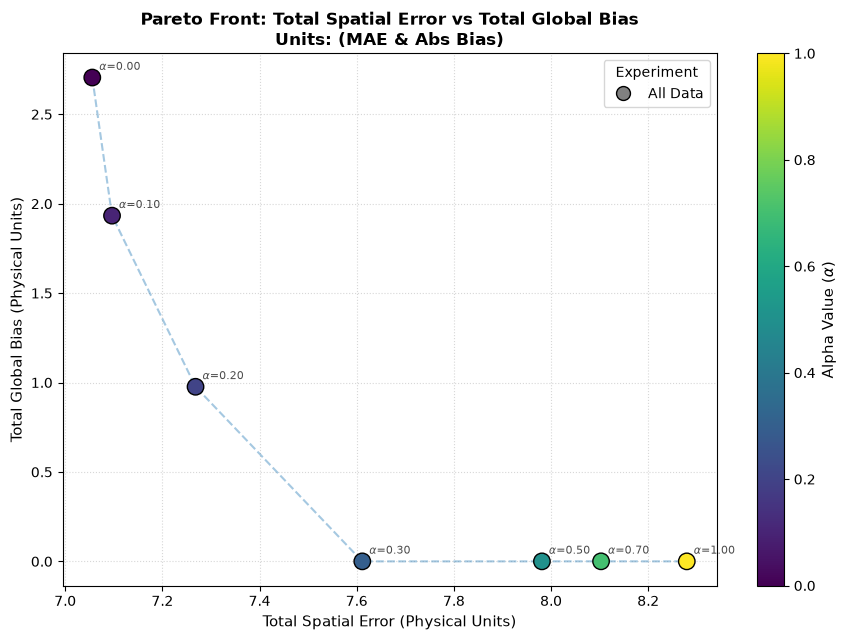

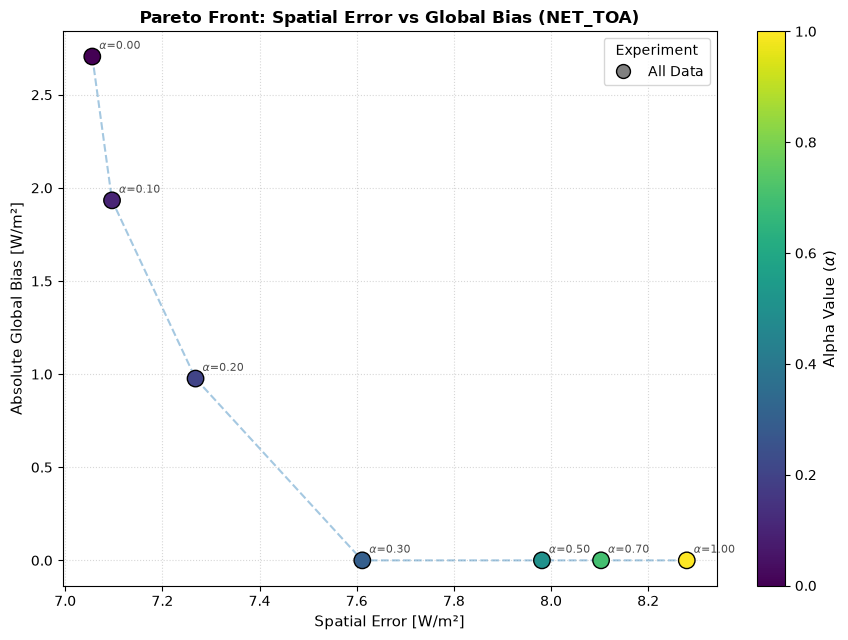


Generating 2D Maps...

Mappe per il run: a05_hybrid

Mappe per il run: a02_spatial

Mappe per il run: a03_spatial

Mappe per il run: a10_global

Mappe per il run: a07_spatial

Mappe per il run: a01_spatial

Mappe per il run: a00_spatial


In [8]:
import os
import glob
from ectuner.libs.diagnostics import (
    load_diagnostic_yamls, 
    build_metrics_dataframe, 
    plot_tradeoff_comparison,
    plot_variable_pareto,
    plot_parameter_heatmap,
    plot_tuning_results_maps
)

out_dir = "/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/tuned_2d_LR/refactor/2d/net_toa/"

# ---------------------------------------------------------
# 1. Parameters and Trade-Off Analysis (based on YAML files)
# ---------------------------------------------------------
print("Yaml upload...")
diag_data = load_diagnostic_yamls("/ec/res4/hpcperm/ecme3038/ecearth/ecearth4/ECtuner/mari/results/diagnostics_2d_LR/refactor/2d/net_toa/")

plot_parameter_heatmap(diag_data)

# pareto front (Spatial Error vs Global Bias)
df_metrics = build_metrics_dataframe(diag_data)
var = 'net_toa'  # Sostituisci con il nome corretto della variabile che vuoi analizzare
display(df_metrics) # Visualizza la tabella interattiva
plot_tradeoff_comparison(df_metrics, group_by='Experiment')
plot_variable_pareto(df_metrics, var=var, group_by='Experiment')

# ---------------------------------------------------------
# 2. Spatial Analysis (based on NetCDF files)
# ---------------------------------------------------------
print("\nGenerating 2D Maps...")
# Find all generated diagnostic NetCDF files
nc_files = glob.glob(os.path.join(out_dir, "diagnostics_2d_*.nc"))

# experiment maps
for nc_file in nc_files:
    run_tag = os.path.basename(nc_file).replace('.nc', '').replace('diagnostics_2d_phis_', '')
    print(f"\nMappe per il run: {run_tag}")
    
    plot_tuning_results_maps(
        diag_file=nc_file, 
        output_dir=os.path.join(out_dir, "plots"), 
        run_tag=run_tag
    )

In [ ]:

# 3. I dati di ECmean (modello reale) li puoi estrarre automaticamente leggendo i file YAML generati dal modello.
# (Supponiamo di avere una funzione `leggi_bias_reali(cartella)`)
data_ecmean = leggi_bias_reali(cartella_output_modello)

# 4. Plot! Senza aver scritto un solo numero a mano.
plot_emulator_performance_global('rsnt', ref_obs, data_ecmean, data_predicted_bias)

da fare: chiedi a gemini confronto tra base maps e global mean e crea script per estrarre valori utili per confronto con emulatore.. integrare ecmean in ectuner ?? come ??

test!!!!